In [1]:
import os
import sys
import argparse

import numpy as np
import matplotlib.pyplot as plt

import torch

import dolfinx
import dolfinx.fem.petsc
import ufl
from mpi4py import MPI
import basix.ufl

repo_path = os.path.abspath(os.path.join(os.getcwd(), "../../"))
sys.path.append(repo_path)

from utils import load_yaml, load_pkl, load_npy, format_elapsed_time, timing, plot_complex_valued_function, plot_real_valued_function, evaluate_expression

from scifem import create_real_functionspace

import torch
import torch.nn as nn
import torch.nn.init as init
import numpy as np
from petsc4py import PETSc
import scifem


from utils import project, norm_L2, convert_petsc_mat_to_torch_sparse_coo_tensor, convert_weight_to_tensor
from typing import Optional
import pickle
import time
from tqdm import tqdm
import matplotlib.ticker as ticker

from data_generation.differential_equations import ElasticityLeastSquares

----------------------------------------
2025-12-11 17:00:23 - Start Program
----------------------------------------


In [2]:
mesh_config_path= repo_path + "/configs/elasticity/config_data/config_mesh.yaml"
function_space_config_path= repo_path + "/configs/elasticity/config_data/config_function_space.yaml"
output_reduced_basis_config_path= repo_path + "/configs/elasticity/config_data/config_output_reduced_basis.yaml"
train_dataset_path = repo_path + "/results/elasticity/train_dataset"
test_dataset_path = repo_path + "/results/elasticity/test_dataset"

In [3]:
# mesh_args['num_x'] = 256
# mesh_args['num_y'] = 128
# function_space_args['u']['degree'] = 2
# function_space_args['sigma']['degree'] = 2

In [4]:
# if mesh_args['num_x'] == 128:
#     p_dof = load_npy(train_dataset_path+'/p_dof.npy')
# elif mesh_args['num_x'] == 256:
#     p_dof = load_npy(train_dataset_path+'/p_dof_4x_resolution.npy')
# else:
#     raise ValueError(f"Unsupported mesh resolution: {mesh_args['num_x']}")
# print(p_dof.shape)

In [5]:
num_samples = 1
mesh_size_list = [2**4, 2**5, 2**6, 2**7, 2**8]
order_list = [0, 1, 2]
scale_list = [16, 8, 4, 2, 1]
different_scales_p_dof_list = []

In [6]:
mesh_args = load_yaml(mesh_config_path)
function_space_args = load_yaml(function_space_config_path)
output_reduced_basis_args = load_yaml(output_reduced_basis_config_path)
mesh_args['num_x'], mesh_args['num_y'] = 256, 128
elasticity_least_squares = ElasticityLeastSquares(mesh_args, function_space_args)
mesh = elasticity_least_squares.mesh
Vh = elasticity_least_squares.Vh

In [7]:
p_dof = load_npy(train_dataset_path + "/p_dof_256x128.npy")[:num_samples,:]

dolfinx_mesh_coords = mesh.geometry.x[:,:2]
num_x, num_y = mesh_args['num_x'], mesh_args['num_y']
x = np.linspace(0, mesh_args['upper_right_x'], num_x+1)
y = np.linspace(0, mesh_args['upper_right_y'], num_y+1)
image_mesh_coords = np.array(np.meshgrid(x, y)).T.reshape(-1, 2)
perm = [np.where((image_mesh_coords == row).all(axis=1))[0][0] for row in dolfinx_mesh_coords]

p_vertex_values = np.zeros((num_samples, (num_x + 1) * (num_y + 1)), dtype='float64')
for i in tqdm(range(num_samples)):
    p_fc = dolfinx.fem.Function(Vh['p'])
    p_fc.x.array[:] = p_dof[i]
    p_vertex_values[i][perm] = evaluate_expression(mesh, p_fc, mesh.geometry.x)[1][:, 0]

100%|██████████| 1/1 [00:02<00:00,  2.21s/it]


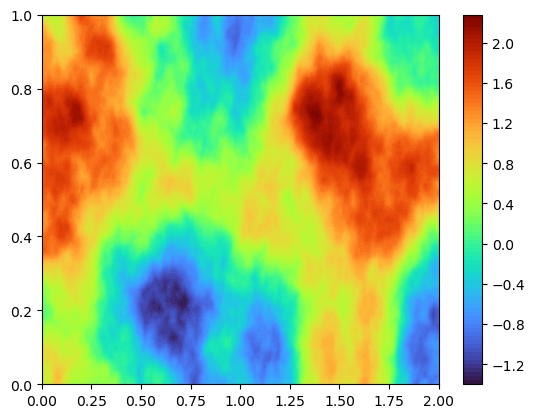

In [8]:
x = mesh.geometry.x[:,0]
y = mesh.geometry.x[:,1]
p_fc = dolfinx.fem.Function(Vh['p'])
p_fc.x.array[:] = p_dof[0]
plt.tricontourf(x, y, evaluate_expression(mesh, p_fc, mesh.geometry.x)[1][:, 0], cmap='turbo', levels=100)
plt.colorbar()
plt.show()

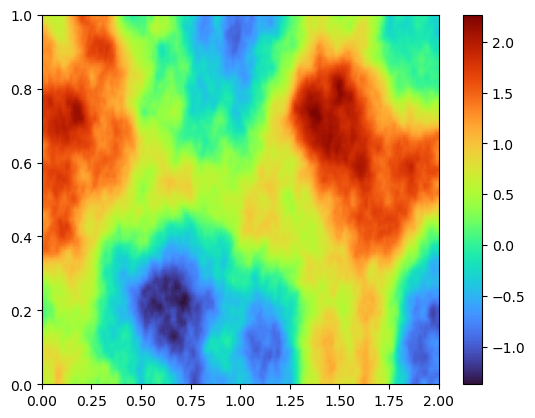

In [9]:
plt.imshow(p_vertex_values[0].reshape(num_x + 1, num_y + 1).T, extent=(0, mesh_args['upper_right_x'], 0, mesh_args['upper_right_y']), origin='lower', cmap='turbo', aspect='auto')
plt.colorbar()
plt.show()

In [10]:
for scale in scale_list:
    image_p_vertex_values = p_vertex_values.reshape(-1, 256 + 1, 128  + 1).transpose(0,2,1)
    downsampled_image_p_vertex_values = image_p_vertex_values[:, ::scale, ::scale]
    downsampled_num_y, downsampled_num_x = downsampled_image_p_vertex_values.shape[1] - 1, downsampled_image_p_vertex_values.shape[2] - 1
    downsampled_p_vertex_values = downsampled_image_p_vertex_values.reshape(-1, (downsampled_num_y + 1) * (downsampled_num_x + 1))

    dolfin_mesh_coords = load_npy(train_dataset_path + "/mesh_coordinates_256x128.npy")
    downsampled_dolfin_mesh_coords = dolfin_mesh_coords.reshape(128 + 1, 256 + 1, 2)[::scale, ::scale, :].reshape(-1, 2)

    mesh_args = load_yaml(mesh_config_path)
    mesh_args['num_x'], mesh_args['num_y'] = downsampled_num_x, downsampled_num_y
    function_space_args = load_yaml(function_space_config_path)
    elasticity_least_squares = ElasticityLeastSquares(mesh_args, function_space_args)
    mesh = elasticity_least_squares.mesh
    Vh = elasticity_least_squares.Vh

    perm = [np.where((downsampled_dolfin_mesh_coords == row).all(axis=1))[0][0] for row in mesh.geometry.x[:,:2]]

    downsampled_p_dim = dolfinx.fem.Function(Vh['p']).x.array.shape[0]
    downsampled_p_dof = np.zeros((num_samples, downsampled_p_dim), dtype='float64')

    for i in tqdm(range(num_samples)):
        p_fc = dolfinx.fem.Function(Vh['p'])
        p_fc.x.array[:] = downsampled_p_vertex_values[i].flatten(order='F')[perm][scifem.dof_to_vertexmap(Vh['p'])]
        downsampled_p_dof[i] = p_fc.x.array[:]

    different_scales_p_dof_list.append(downsampled_p_dof)

100%|██████████| 1/1 [00:00<00:00, 5133.79it/s]


100%|██████████| 1/1 [00:00<00:00, 373.19it/s]


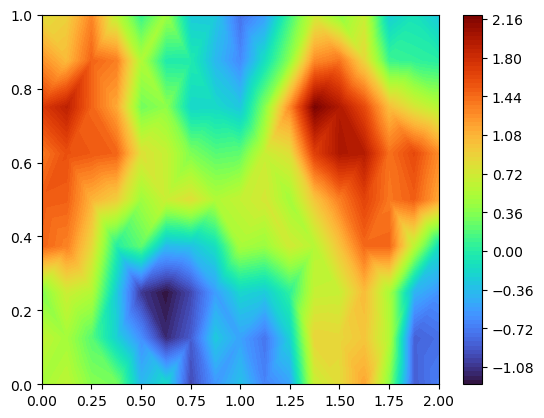

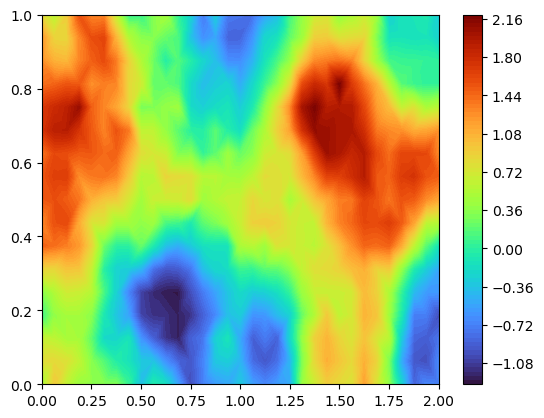

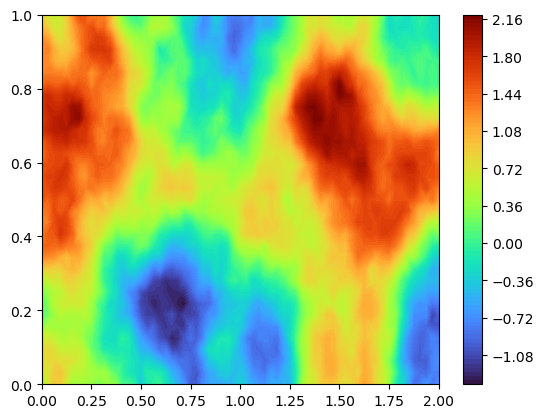

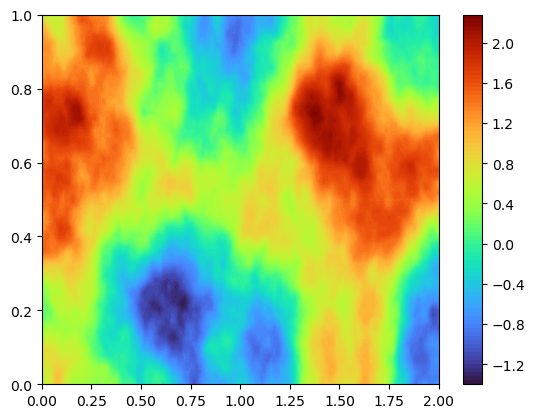

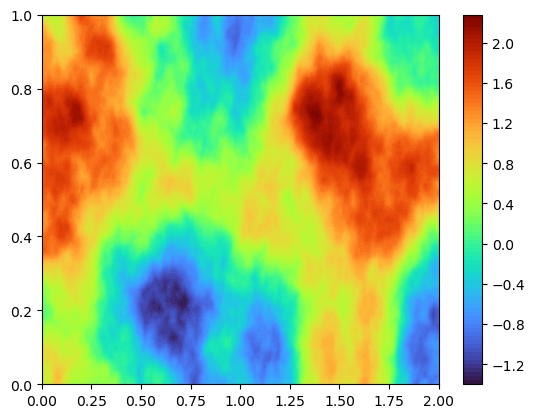

In [11]:
for i, mesh_size in enumerate(mesh_size_list):
    mesh_args['num_x'] = mesh_size
    mesh_args['num_y'] = int(mesh_size / 2)

    elasticity_least_squares = ElasticityLeastSquares(mesh_args, function_space_args)
    mesh = elasticity_least_squares.mesh
    Vh = elasticity_least_squares.Vh

    p_fc = dolfinx.fem.Function(Vh['p'], dtype='float64')
    p_fc.x.array[:] = different_scales_p_dof_list[i][0, :]

    x = mesh.geometry.x[:, 0]
    y = mesh.geometry.x[:, 1]
    plt.tricontourf(x, y, evaluate_expression(mesh, p_fc, mesh.geometry.x)[1][:, 0], cmap='turbo', levels=100)
    plt.colorbar()
    plt.show()


In [12]:
torch_dtype = {
    'float16': torch.float16,
    'float32': torch.float32,
    'float64': torch.float64,
}

In [13]:
analysis_reference_loss_array = np.zeros((len(order_list), len(mesh_size_list)))

In [14]:
for mesh_size in mesh_size_list:
    for order in order_list:
        print(f"mesh size: {mesh_size}, order: {order}")
        mesh_args['num_x'] = mesh_size
        mesh_args['num_y'] = int(mesh_size / 2)
        function_space_args['u']['degree'] = order+1
        function_space_args['sigma']['degree'] = order+1  # this corresponds to RT(order)xCG(order+1), note that in FEniCSx: RT's degree input argument is order+1 for RT(order)
        function_space_args['w']['degree'] = order+1
        function_space_args['q']['degree'] = order+1

        elasticity_least_squares = ElasticityLeastSquares(mesh_args, function_space_args)
        mesh = elasticity_least_squares.mesh
        Vh = elasticity_least_squares.Vh

        p_dof = different_scales_p_dof_list[mesh_size_list.index(mesh_size)]

        sigma_u_dim = dolfinx.fem.Function(Vh['sigma_u']).x.array.shape[0]
        sigma_dim = dolfinx.fem.Function(Vh['sigma']).x.array.shape[0]
        u_dim = dolfinx.fem.Function(Vh['u']).x.array.shape[0]
        dtype = 'float64'

        sigma_u_dof = np.zeros((num_samples, sigma_u_dim), dtype=dtype)
        sigma_dof = np.zeros((num_samples, sigma_dim), dtype=dtype)
        u_dof = np.zeros((num_samples, u_dim), dtype=dtype)

        for i in tqdm(range(num_samples)):
            p = dolfinx.fem.Function(Vh['p'], dtype=dtype)
            p.x.array[:] = p_dof[i,:]
            sigma_u = elasticity_least_squares.solve_sigma_u(p=p)
            sigma = sigma_u.sub(0).collapse()
            u = sigma_u.sub(1).collapse()
            sigma_u_dof[i,:] = sigma_u.x.array
            sigma_dof[i,:] = sigma.x.array
            u_dof[i,:] = u.x.array
        
        reference_loss_list = []
        for i in tqdm(range(num_samples)):
            p_fc = dolfinx.fem.Function(Vh['p'], dtype=dtype)  
            p_fc.x.array[:] = p_dof[i]
            weight = elasticity_least_squares.compute_weight(p_fc)
            weight_tensor = convert_weight_to_tensor(weight, dtype=torch_dtype['float64'])

            y = sigma_u_dof[i]
            y = torch.tensor(y, dtype=torch_dtype['float64'])
            reference_loss = torch.dot(y, weight_tensor['A00'] @ y) + 2*torch.dot(y, weight_tensor['A01'])  + weight_tensor['A11']
            print(f'reference loss: {reference_loss.item()}')
            reference_loss_list.append(reference_loss.item())

        analysis_reference_loss_array[order_list.index(order), mesh_size_list.index(mesh_size)] = np.mean(reference_loss_list)

mesh size: 16, order: 0


100%|██████████| 1/1 [00:00<00:00, 15.01it/s]


reference loss: 0.05312809530056717
mesh size: 16, order: 1


100%|██████████| 1/1 [00:00<00:00,  9.42it/s]


reference loss: 0.00694637213980942
mesh size: 16, order: 2


...

reference loss: 0.0019105446990884678
mesh size: 256, order: 1


100%|██████████| 1/1 [00:17<00:00, 17.75s/it]


reference loss: 0.0001781772294011108
mesh size: 256, order: 2


100%|██████████| 1/1 [00:56<00:00, 56.12s/it]

reference loss: 7.275733140399421e-05


In [15]:
np.savetxt(os.path.join(train_dataset_path, f"analysis_reference_loss_decay_wrt_mesh_size_and_order_with_num_samples_{num_samples}.txt"), analysis_reference_loss_array)

In [6]:
analysis_reference_loss_array = np.loadtxt(os.path.join(train_dataset_path, f"analysis_reference_loss_decay_wrt_mesh_size_and_order_with_num_samples_{num_samples}.txt"))

In [7]:
analysis_reference_loss_array

array([[5.31280953e-02, 3.26534913e-02, 1.47548647e-02, 5.50158764e-03,
        1.91054470e-03],
       [6.94637214e-03, 2.88530653e-03, 1.11085758e-03, 4.39890976e-04,
        1.78177229e-04],
       [2.75182657e-03, 1.11461087e-03, 4.43801173e-04, 1.78468534e-04,
        7.27573314e-05]])

In [8]:
# weight['A00']

In [9]:
# from petsc4py import PETSc
# from slepc4py import SLEPc

# # Assume your PETSc matrix is named A and is of type petsc4py.PETSc.Mat

# # 1. Create an eigensolver
# E = SLEPc.EPS().create()
# E.setOperators(weight['A00'])
# E.setProblemType(SLEPc.EPS.ProblemType.HEP)  # Hermitian eigenvalue problem if symmetric

# # 2. Configure solver options
# E.setDimensions(nev=1)  # we want the smallest one
# E.setWhichEigenpairs(SLEPc.EPS.Which.SMALLEST_REAL)
# E.setFromOptions()      # allows runtime control via command line options

# # 3. Solve the eigenproblem
# E.solve()

# # 4. Extract results
# nconv = E.getConverged()
# if nconv > 0:
#     vr, vi = weight['A00'].getVecs()
#     eigenvalue = E.getEigenpair(0, vr, vi)
#     print("Smallest eigenvalue:", eigenvalue)
# else:
#     print("No eigenvalues converged.")

In [10]:
inverse_mesh_size_list = [2/h for h in mesh_size_list] # since the domain is [0,2]x[0,1]

In [11]:
reference_loss = np.zeros((len(order_list), len(mesh_size_list)))
for i, order in enumerate(order_list):
    for j in range(len(mesh_size_list)):
        reference_loss[i, j] = inverse_mesh_size_list[j]**(2*(order+1))

In [12]:
markers = ['o', 's', '^', 'D', 'v', '>', '<', 'p', '*', 'h']  # add more if needed

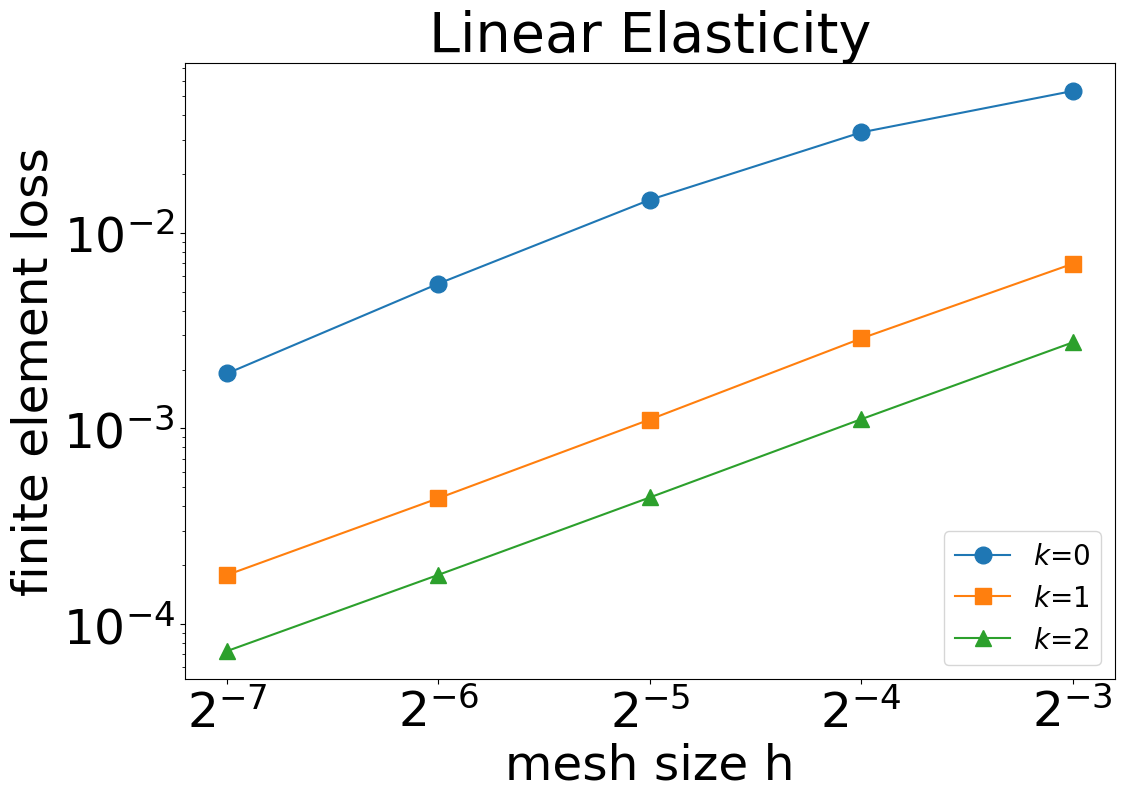

In [20]:
plt.figure(figsize=(12,8))
for i, order in enumerate(order_list):
    marker = markers[i % len(markers)]
    color = plt.cm.tab10(i % 10)  # or plt.gca()._get_lines.get_next_color()
    plt.loglog(inverse_mesh_size_list, analysis_reference_loss_array[i], marker=marker, markersize=12,  label=rf'$k$={order}', color=color)

plt.yscale('log', base=10)
plt.xscale('log', base=2)
plt.xlabel('mesh size h', fontsize=35)
plt.ylabel('finite element loss', fontsize=35)
plt.tick_params(axis='both', which='major', labelsize=35)
plt.legend(fontsize=20, loc='lower right')
plt.title('Linear Elasticity', fontsize=40)
plt.savefig(os.path.join(train_dataset_path, f"analysis_reference_loss_decay_wrt_mesh_size_and_order_with_num_samples_{num_samples}.png"), dpi=300, bbox_inches='tight')
plt.show()

In [14]:
analysis_reference_loss_array

array([[5.31280953e-02, 3.26534913e-02, 1.47548647e-02, 5.50158764e-03,
        1.91054470e-03],
       [6.94637214e-03, 2.88530653e-03, 1.11085758e-03, 4.39890976e-04,
        1.78177229e-04],
       [2.75182657e-03, 1.11461087e-03, 4.43801173e-04, 1.78468534e-04,
        7.27573314e-05]])

In [15]:
reference_loss

array([[1.56250000e-02, 3.90625000e-03, 9.76562500e-04, 2.44140625e-04,
        6.10351562e-05],
       [2.44140625e-04, 1.52587891e-05, 9.53674316e-07, 5.96046448e-08,
        3.72529030e-09],
       [3.81469727e-06, 5.96046448e-08, 9.31322575e-10, 1.45519152e-11,
        2.27373675e-13]])

In [16]:
multiplier = analysis_reference_loss_array[:, 0] / reference_loss[:, 0]

In [17]:
temp = np.zeros((1, len(mesh_size_list)))
for j in range(len(mesh_size_list)):
    temp[0, j] = inverse_mesh_size_list[j]**(1.5)
temp_multiplier = analysis_reference_loss_array[1, 0] / temp[0, 0]

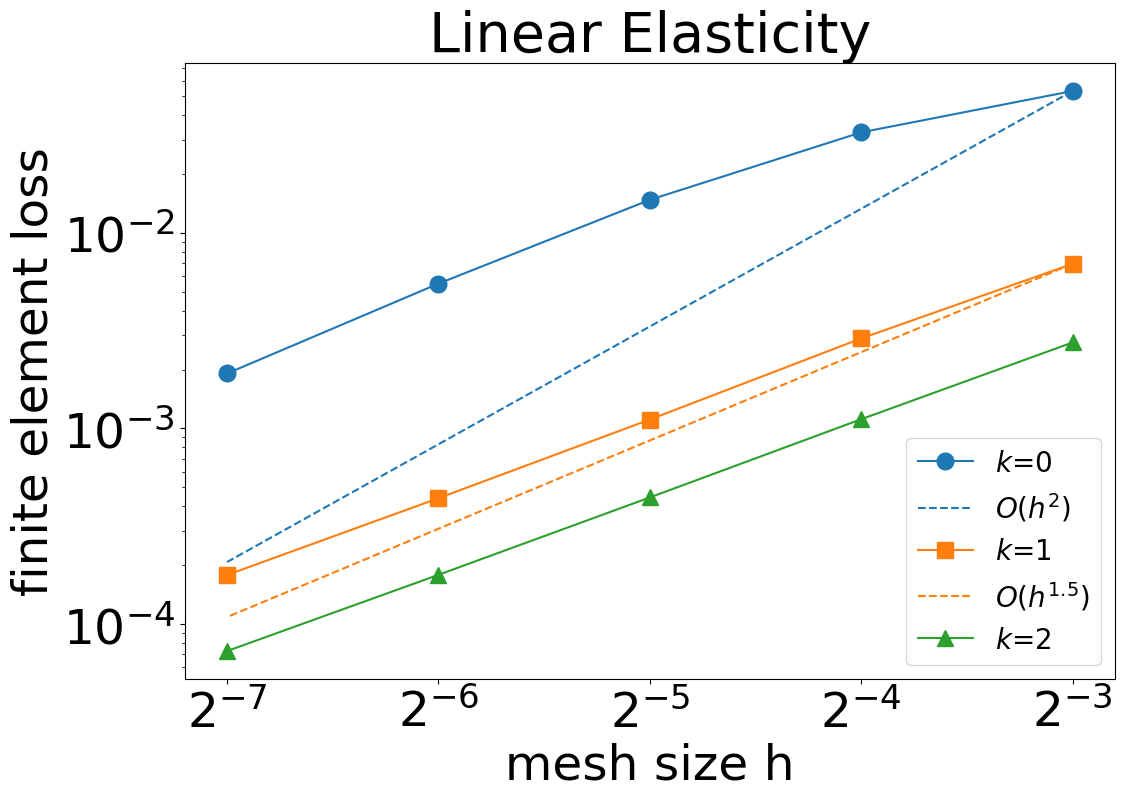

In [19]:
plt.figure(figsize=(12,8))
for i, order in enumerate(order_list):
    marker = markers[i % len(markers)]
    color = plt.cm.tab10(i % 10)  # or plt.gca()._get_lines.get_next_color()
    plt.loglog(inverse_mesh_size_list, analysis_reference_loss_array[i], marker=marker, markersize=12, label=rf'$k$={order}', color=color)
    if i == 0:
        plt.loglog(inverse_mesh_size_list, multiplier[i] * reference_loss[i], linestyle='--', label=rf'$O(h^{{{2*(order+1)}}})$', color=color)
    elif i == 1:
        plt.loglog(inverse_mesh_size_list, temp_multiplier * temp[0], linestyle='--', label=r'$O(h^{{1.5}})$', color=color)

plt.yscale('log', base=10)
plt.xscale('log', base=2)
plt.xlabel('mesh size h', fontsize=35)
plt.ylabel('finite element loss', fontsize=35)
plt.tick_params(axis='both', which='major', labelsize=35)
plt.legend(fontsize=20, loc='lower right')
plt.title('Linear Elasticity', fontsize=40)
plt.savefig(os.path.join(train_dataset_path, f"analysis_reference_loss_decay_wrt_mesh_size_and_order_with_num_samples_{num_samples}_with_dash_lines.png"), dpi=300, bbox_inches='tight')
plt.show()